# Diagnóstico de Hardware e PyTorch

Esta célula verifica se o PyTorch consegue acessar sua GPU (CUDA).

In [20]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("Motivo: Provavelmente a versão do Torch instalada é 'cpu-only' ou os drivers NVIDIA não estão configurados.")
    try:
        from torch.utils import cpp_extension
        print(f"CUDA Home: {cpp_extension.CUDA_HOME}")
    except:
        print("Não foi possível localizar o CUDA Home.")
else:
    print(f"GPU Detectada: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cu124
CUDA disponível: True
GPU Detectada: NVIDIA GeForce GTX 1660 SUPER


# Implementação da Arquitetura LeNet-5

Este notebook contém a declaração do modelo LeNet-5 utilizando PyTorch, visualização dos dados e o código de treinamento.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1: 6 filtros de 5x5, stride 1. Adicionado padding=2 para ajustar 28x28 para 32x32 internamente
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        # S2: Max Pooling 2x2, stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C3: 16 filtros de 5x5, stride 1
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        # S4: Max Pooling 2x2, stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Camada Flatten para robustez
        self.flatten = nn.Flatten()
        
        # Camadas densas
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instanciando o modelo com detecção automática
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5(num_classes=10).to(device)

print(f"Modelo carregado no dispositivo: {device}")

Modelo carregado no dispositivo: cuda


### Visualização dos Filtros (Estado Inicial)

Os filtros da primeira camada convolucional antes de qualquer treinamento.

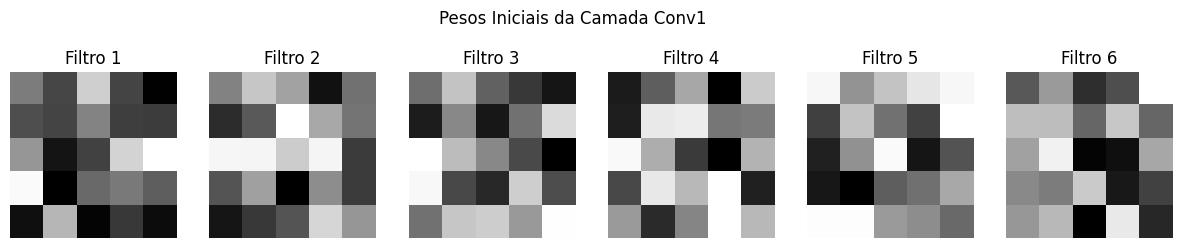

In [22]:
import matplotlib.pyplot as plt

kernels = model.conv1.weight.detach().cpu()
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(kernels[i][0], cmap='gray')
    ax.set_title(f'Filtro {i+1}')
    ax.axis('off')
plt.suptitle("Pesos Iniciais da Camada Conv1")
plt.show()

### Carregamento e Visualização do MNIST

Vamos carregar o dataset MNIST usando `torchvision` e visualizar alguns exemplos.

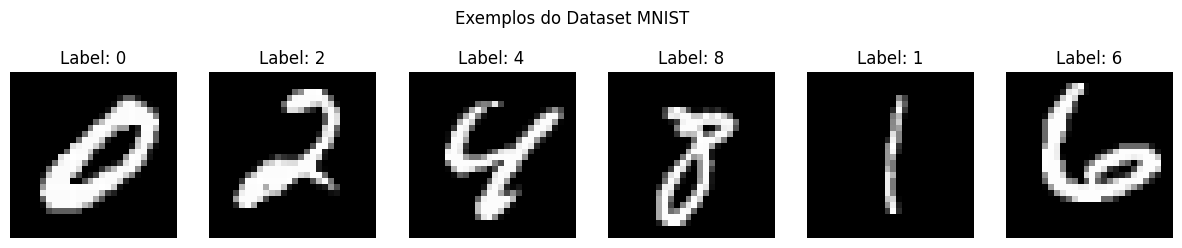

In [23]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformação básica: converter para tensor
transform = transforms.Compose([transforms.ToTensor()])

# Download do dataset de treino
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader_viz = DataLoader(train_dataset, batch_size=6, shuffle=True)

# Obtendo um batch de exemplos para visualização
images_viz, labels_viz = next(iter(train_loader_viz))

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(images_viz[i][0], cmap='gray')
    ax.set_title(f'Label: {labels_viz[i].item()}')
    ax.axis('off')
plt.suptitle("Exemplos do Dataset MNIST")
plt.show()

### Feature Maps: Visualizando o resultado da primeira camada

Vamos ver como uma imagem do MNIST é transformada após passar pela primeira camada convolucional (`conv1`). Isso nos mostra quais características os filtros estão extraindo.

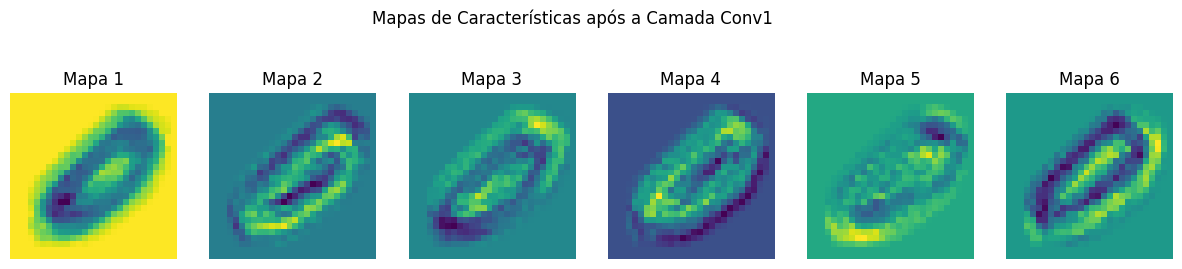

In [24]:
model.eval()
with torch.no_grad():
    # Pegamos uma única imagem do batch de visualização
    single_img = images_viz[0].unsqueeze(0).to(device)
    
    # Aplicamos apenas a primeira camada convolucional
    feature_maps = model.conv1(single_img)

    # Visualização dos 6 mapas de características resultantes
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(feature_maps[0, i].cpu(), cmap='viridis')
        ax.set_title(f'Mapa {i+1}')
        ax.axis('off')
    
    plt.suptitle("Mapas de Características após a Camada Conv1", y=1.05)
    plt.show()

### Treinamento da Rede Neural

Nesta célula, definimos o otimizador, a função de perda e executamos o loop de treinamento.

In [25]:
import torch.optim as optim

# Hiperparâmetros
learning_rate = 0.001
epochs = 5
batch_size = 64

# Dataloaders (Treino e Teste definitivo)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Perda e Otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Loop de Treinamento
print(f"Iniciando treinamento no dispositivo: {device}")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward e Otimização
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    # Validação simples após cada época
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    print(f'Época [{epoch+1}/{epochs}], Perda: {running_loss/len(train_loader):.4f}, Acurácia no Teste: {100 * correct / total:.2f}%')

print("Treinamento concluído!")

Iniciando treinamento no dispositivo: cuda
Época [1/5], Perda: 0.2679, Acurácia no Teste: 97.84%
Época [2/5], Perda: 0.0730, Acurácia no Teste: 98.29%
Época [3/5], Perda: 0.0531, Acurácia no Teste: 98.73%
Época [4/5], Perda: 0.0425, Acurácia no Teste: 98.87%
Época [5/5], Perda: 0.0346, Acurácia no Teste: 98.53%
Treinamento concluído!


### Análise de Erros (Misclassified Examples)

É fundamental entender onde a rede está falhando. Vamos buscar imagens onde a predição foi diferente do rótulo real.

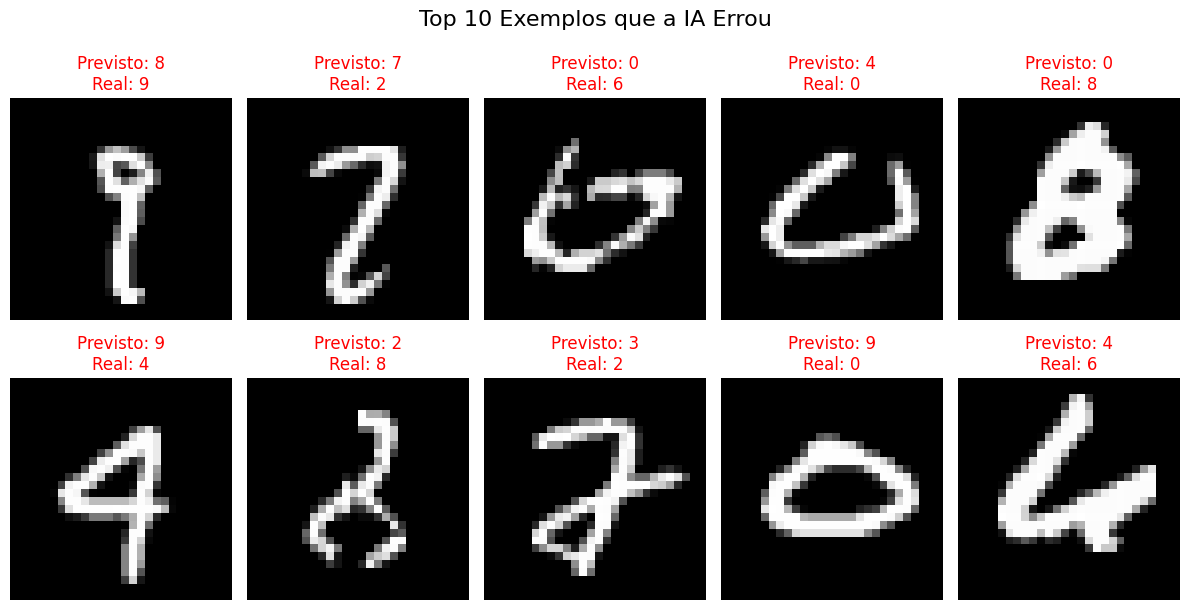

In [26]:
model.eval()
misclassified_images = []
misclassified_labels = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, predicted = torch.max(outputs, 1)
        
        # Filtra apenas os erros
        mask = predicted.cpu() != labels
        if mask.any():
            misclassified_images.extend(images[mask])
            misclassified_labels.extend(predicted.cpu()[mask])
            true_labels.extend(labels[mask])
        
        if len(misclassified_images) >= 10: # Pega as 10 primeiras falhas
            break

# Visualizando os 10 primeiros erros
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(misclassified_images):
        ax.imshow(misclassified_images[i][0], cmap='gray')
        ax.set_title(f'Previsto: {misclassified_labels[i].item()}\nReal: {true_labels[i].item()}', color='red')
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Top 10 Exemplos que a IA Errou", y=1.05, fontsize=16)
plt.show()

### Salvando o Modelo Treinado

É importante salvar os pesos do modelo (`state_dict`) para que possamos carregá-lo posteriormente sem precisar treinar novamente.

In [27]:
import os

save_dir = 'models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

model_path = os.path.join(save_dir, 'lenet5_mnist.pth')
torch.save(model.state_dict(), model_path)
print(f"Modelo salvo com sucesso em: {os.path.abspath(model_path)}")

Modelo salvo com sucesso em: d:\Devs\DevProjs\lenet\models\lenet5_mnist.pth


### Carregando um Modelo Existente

Caso você queira testar o carregamento ou usar o modelo em outro momento.

In [28]:
# 1. Instanciar a classe do modelo
new_model = LeNet5(num_classes=10).to(device)

# 2. Carregar os pesos salvos
# Certifique-se de usar weights_only=True por segurança se estiver usando Torch recente
model_load_path = os.path.join('models', 'lenet5_mnist.pth')
new_model.load_state_dict(torch.load(model_load_path, map_location=device))

# 3. Colocar em modo de avaliação
new_model.eval()

print("Modelo carregado com sucesso dos arquivos!")

Modelo carregado com sucesso dos arquivos!
